# 02 — Recreating Maharjan *et al.* (2013): the Stackelberg demand-response game

**Repository:** `stackelberg-dr-real-feeder` · **Milestone 1, notebook 2 of 2**

> S. Maharjan, Q. Zhu, Y. Zhang, S. Gjessing, T. Başar, **"Dependable Demand
> Response Management in the Smart Grid: A Stackelberg Game Approach,"** *IEEE
> Transactions on Smart Grid*, vol. 4, no. 1, pp. 120–132, 2013.
> DOI: [10.1109/TSG.2012.2223766](https://doi.org/10.1109/TSG.2012.2223766)

⚠️ **This is an independent, unofficial educational recreation.** It is not
affiliated with or endorsed by the authors. All numbers here are produced by our
own implementation; where they match the paper we say so with evidence, and where
the paper could not be reproduced from its stated parameters we say that too (see
§7 and `LEDGER.md`). Model extraction notes with all equation references:
[`docs/model_extraction.md`](../docs/model_extraction.md).

**Scope.** We recreate the core game (paper Sections III–V): the multi-leader
multi-follower Stackelberg game, its unique equilibrium in closed form, the
numerical results (Figs. 4–8), and the distributed local-information algorithm
(Algorithm 2, Figs. 9–13). We do **not** recreate Section VI (price-attack and
reserve-power schemes) — out of scope for this milestone.

**Why this paper, of all papers?** It is the canonical Stackelberg formulation of
demand response — analytically solvable end-to-end, so every later, messier layer
of this repository (real feeder physics in M2, learning agents in M3, fairness in
M4) can be graded against an *exact* ground truth. And its distributed algorithm
(eq. 44) is, to a power engineer, an old friend wearing new clothes: an integral
controller driving excess demand to zero.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sgdr.plotting import apply_style, PALETTE, savefig
from sgdr import model as M
from sgdr import distributed as D

apply_style()
RESULTS = pathlib.Path("../results/m1"); RESULTS.mkdir(parents=True, exist_ok=True)
np.set_printoptions(precision=4, suppress=True)

## §1 · The cast, in power terms

Two kinds of players:

- **$K$ utility companies (UCs)** — the *leaders*. UC $k$ owns available power
  $P_k$ (already-procured generation, "units" of energy) and announces a unit
  price $y_k$. Its payoff is pure revenue, $U_{\text{gen},k} = y_k \sum_n x_{n,k}$
  (eq. 24). No storage is assumed, so unsold power is worthless — every UC wants
  to **sell all of $P_k$** (eq. 26 as an equality).
- **$N$ households** — the *followers*. Household $n$ sees all prices and chooses
  how much to buy from each UC, $x_{n,k}$, to maximize a log-utility of total
  consumption (eq. 1) under a hard **budget** $C_n$ (eq. 3) — the affordability
  cap. β keeps the log finite at zero (β = 1 throughout).

The **timing** makes it Stackelberg: UCs commit prices first (playing a
*simultaneous* pricing game among themselves), households then respond optimally.
The equilibrium of the whole two-level object — prices from which no UC deviates,
demands that are optimal against those prices — is the **Stackelberg equilibrium
(SE)**, and the paper's central results are that it *exists*, is *unique*
(Theorems 1–4), and is *reachable with local information only* (Theorem 5).

**What is deliberately absent** (and arrives in Milestone 2): any notion of a
network. No feeder, no voltage, no losses, no location — energy flows from any UC
to any household as if on a copper plate. Keep noticing this as we go.

The paper's base numerical case (Section VII):

In [2]:
g = M.paper_base_game(C1=5.0)   # C_1 is swept 2..42 later, 5 is the base
users = pd.DataFrame({"alpha": g.alpha, "beta": g.beta, "budget C_n": g.C},
                     index=[f"user {n+1}" for n in range(g.N)])
ucs = pd.DataFrame({"available power P_k": g.P},
                   index=[f"UC {k+1}" for k in range(g.K)])
print(users, "\n"); print(ucs)
print(f"\ntotals: B = Σβ = {g.B:.0f},  C = ΣC_n = {g.Ctot:.0f},  ΣP = {g.P.sum():.0f}")

        alpha  beta  budget C_n
user 1    1.0   1.0         5.0
user 2    1.0   1.0        10.0
user 3    1.0   1.0        15.0
user 4    1.0   1.0        20.0
user 5    1.0   1.0        25.0 

      available power P_k
UC 1                 10.0
UC 2                 15.0
UC 3                 20.0

totals: B = Σβ = 5,  C = ΣC_n = 75,  ΣP = 45


## §2 · The household's problem, solved by hand

Household $n$ solves (eqs. 2–4):

$$\max_{x_{n,1},\dots,x_{n,K}\,\ge 0}\ \alpha_n\sum_{k}\ln(\beta_n + x_{n,k})
\qquad \text{s.t.}\qquad \sum_k y_k\,x_{n,k} \le C_n$$

Concave objective, linear constraints ⇒ convex problem ⇒ unique optimum. The
Lagrangian walk-through (paper eqs. 8–20) compresses into two statements a power
engineer will find familiar:

1. **The budget binds.** Marginal utility is positive at every finite $x$, so the
   household spends everything: $\sum_k y_k x_{n,k} = C_n$. (Nothing is saved —
   like a dispatch where all available "generation" — here, budget — is committed.)
2. **Equal marginal bang per rupee.** At the optimum, the marginal utility per
   unit of money must be equal across UCs:
   $\dfrac{\alpha_n}{y_k(\beta_n + x_{n,k})} = \lambda_n\ \ \forall k$ — otherwise
   the household would shift a rupee from the low-bang UC to the high-bang one.
   This is *exactly* the equal-incremental-cost criterion of economic dispatch
   ($dC_g/dP_g = \lambda\ \forall g$), with money as the dispatched resource.

Solving those two conditions gives the closed-form interior best response,
**eq. (21)**:

$$\boxed{\;x_{n,k} \;=\; \frac{C_n + \beta_n\sum_{g} y_g}{K\,y_k} \;-\; \beta_n\;}$$

with corner logic (paper Cases 2–3) when a UC prices itself out of household $n$'s
basket: drop that UC, re-split the budget over the rest — a KKT active-set step,
implemented in `sgdr.model.best_response`.

**Trust but verify.** Before using the formula everywhere, we check it against a
generic numerical optimizer (SLSQP) on many random price vectors, including ones
that trigger the corner cases:

In [3]:
rng = np.random.default_rng(42)
rows = []
worst = 0.0
for trial in range(40):
    y = rng.uniform(0.3, 4.0, size=g.K)     # wide range: provokes corner cases
    xa = M.best_response(g, y)
    for n in range(g.N):
        xn = M.best_response_numerical(g, y, n)
        dev = np.abs(xa[n] - xn).max()
        worst = max(worst, dev)
        if trial < 3:
            rows.append({"trial": trial, "user": n + 1,
                         "closed-form x_n": np.round(xa[n], 4),
                         "SLSQP x_n": np.round(xn, 4),
                         "max |Δ|": f"{dev:.1e}"})
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nWORST deviation over 40 random price vectors x 5 users: {worst:.2e}")
assert worst < 1e-3, 'closed form disagrees with numerical optimum!'


 trial  user           closed-form x_n                 SLSQP x_n max |Δ|
     0     1  [0.4292, 1.3502, 0.3005]  [0.4292, 1.3502, 0.3005] 6.9e-07
     0     2   [0.956, 2.2165, 0.7798]   [0.956, 2.2165, 0.7798] 1.4e-07
     0     3  [1.4828, 3.0828, 1.2592]  [1.4828, 3.0828, 1.2592] 1.1e-07
     0     4  [2.0096, 3.9492, 1.7386]  [2.0096, 3.9492, 1.7386] 1.7e-06
     0     5  [2.5365, 4.8155, 2.2179]  [2.5365, 4.8155, 2.2179] 6.9e-07
     1     1  [0.4395, 5.3939, 0.0605]  [0.4395, 5.3939, 0.0605] 2.1e-06
     1     2  [1.0182, 7.9641, 0.4867]  [1.0182, 7.9641, 0.4867] 1.3e-06
     1     3  [1.5968, 10.5343, 0.913]  [1.5968, 10.5343, 0.913] 7.2e-07
     1     4 [2.1755, 13.1045, 1.3393] [2.1755, 13.1045, 1.3393] 6.6e-07
     1     5 [2.7541, 15.6747, 1.7656] [2.7541, 15.6747, 1.7656] 4.0e-06
     2     1   [0.2942, 0.257, 4.2103]   [0.2942, 0.257, 4.2103] 9.3e-08
     2     2   [0.829, 0.7764, 6.3636]   [0.829, 0.7764, 6.3636] 5.8e-07
     2     3  [1.3638, 1.2959, 8.5168]  [1.3638, 1.

Agreement at the optimizer's own tolerance (~10⁻⁵) across 200 solved problems,
corners included — **eq. (21) is implemented faithfully.** Every result below
rests on this cell.

### What the demand formula *says*

Read eq. (21) like a load characteristic. Household $n$'s **spend** at UC $k$ is
$y_k x_{n,k} = \frac{C_n + \beta_n \sum_g y_g}{K} - \beta_n y_k$: an equal split
of an "augmented budget" across the $K$ UCs, minus a linear penalty on expensive
UCs. Demand itself is (near-)inversely proportional to price — elastic, like a
constant-power load's current vs. voltage:

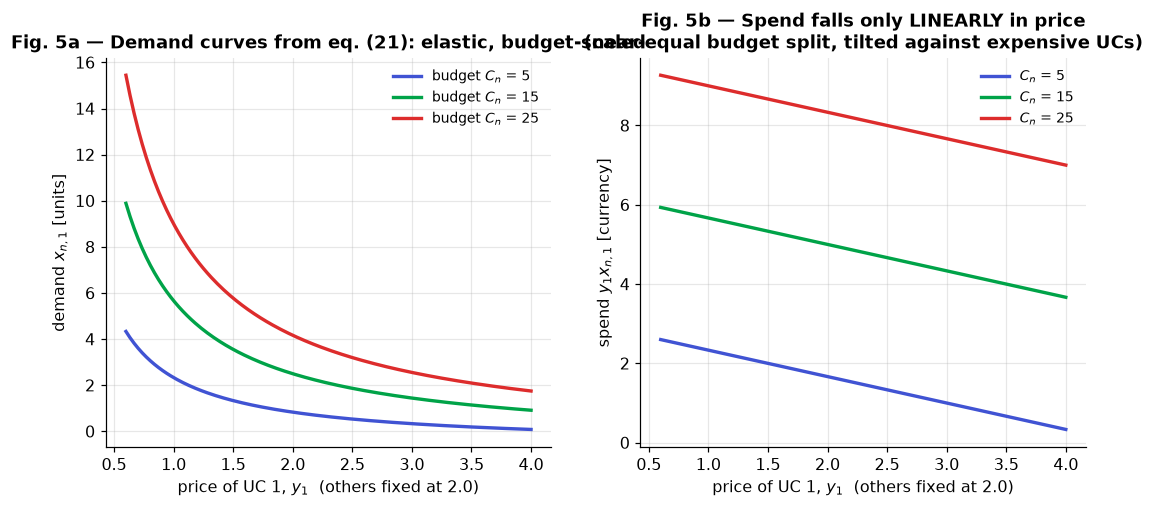

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

y_base = np.array([2.0, 2.0, 2.0])
yk_grid = np.linspace(0.6, 4.0, 200)
ax = axes[0]
for Cn, color in zip([5, 15, 25], PALETTE):
    gg = M.Game(alpha=[1], beta=[1], C=[Cn], P=g.P)
    xk = [M.best_response(gg, np.array([yk, 2.0, 2.0]))[0, 0] for yk in yk_grid]
    ax.plot(yk_grid, xk, lw=2.2, color=color, label=f"budget $C_n$ = {Cn}")
ax.set_xlabel("price of UC 1, $y_1$  (others fixed at 2.0)")
ax.set_ylabel("demand $x_{n,1}$ [units]")
ax.set_title("Fig. 5a — Demand curves from eq. (21): elastic, budget-scaled")
ax.legend(fontsize=9)

ax = axes[1]
share = np.linspace(0.6, 4.0, 200)
for Cn, color in zip([5, 15, 25], PALETTE):
    gg = M.Game(alpha=[1], beta=[1], C=[Cn], P=g.P)
    spend = [M.best_response(gg, np.array([yk, 2.0, 2.0]))[0, 0] * yk for yk in share]
    ax.plot(share, spend, lw=2.2, color=color, label=f"$C_n$ = {Cn}")
ax.set_xlabel("price of UC 1, $y_1$  (others fixed at 2.0)")
ax.set_ylabel("spend $y_1 x_{n,1}$ [currency]")
ax.set_title("Fig. 5b — Spend falls only LINEARLY in price\n(near-equal budget split, tilted against expensive UCs)")
ax.legend(fontsize=9)
savefig(fig, RESULTS / "fig05_demand_curves.png")
plt.show()

**Reading.** Left: demand against a UC's price is a hyperbola-like curve scaled
by budget — richer households are simply scaled-up versions of poorer ones (the
log utility's doing). Right: the *spend* view shows the tilt mechanism — as UC 1
raises its price, household money drains linearly toward the other UCs. This
linear drain is what disciplines the UCs' pricing game: **price high and you lose
basket share.** With that, over to the leaders.

## §3 · The UCs' pricing game and the closed-form equilibrium

Each UC $k$ wants to sell exactly its available power $P_k$ (unsold = wasted,
oversold = infeasible). Impose the sell-all condition on the aggregate of
eq. (21) — sum household demand at UC $k$ over all $n$:

$$\sum_n x_{n,k} \;=\; \frac{C + B\sum_g y_g}{K\,y_k} - B \;\stackrel{!}{=}\; P_k,
\qquad B \equiv \sum_n \beta_n,\quad C \equiv \sum_n C_n$$

Rearranged, this is **linear in the price vector** $\mathbf y$ (paper eqs. 30–33):

$$\mathbf A\,\mathbf y = \mathbf F,\qquad
\mathbf A = \begin{bmatrix} P_1 + D & -E & \cdots \\ -E & P_2 + D & \cdots \\ \vdots & & \ddots \end{bmatrix},
\quad D = \tfrac{B(K-1)}{K},\ E = \tfrac{B}{K},\ \mathbf F = \tfrac{C}{K}\mathbf 1$$

A power engineer sees the structure at a glance: $\mathbf A$ looks like a
**nodal admittance matrix** — strong positive diagonal ($P_k + D$), weak negative
off-diagonals ($-E$), strictly diagonally dominant. The paper's Theorem 1 uses
exactly the argument we use for Y-bus solvability: diagonal dominance ⇒
nonsingular (and here, ⇒ a *positive* price vector). Theorem 4 adds uniqueness of
the Nash equilibrium among UCs, hence a unique Stackelberg equilibrium overall.

*(The paper also gives a determinant closed form, eq. 38; it is typographically
garbled in the scan, so we solve the linear system directly — which is what
eq. 38 is derived from. Nothing is lost; see LEDGER.)*

In [5]:
A, F = M.price_system(g)
print("A =\n", A)
print("F =", F)
dd = np.abs(np.diag(A)) - (np.abs(A).sum(axis=1) - np.abs(np.diag(A)))
print("\nstrict diagonal dominance margins (must be > 0):", dd)

y_star, x_star = M.stackelberg_equilibrium(g)
print("\nequilibrium prices y* =", y_star)
print("all positive (Theorem 1):", bool(np.all(y_star > 0)))

# The two hard consistency checks — both must hold EXACTLY at equilibrium:
print("\nsell-all check  Σ_n x_nk vs P_k :", M.capacity_check(g, x_star), " vs ", g.P)
print("budget check    Σ_k y_k x_nk vs C_n:", M.budget_check(g, y_star, x_star), " vs ", g.C)

A =
 [[13.3333 -1.6667 -1.6667]
 [-1.6667 18.3333 -1.6667]
 [-1.6667 -1.6667 23.3333]]
F = [25. 25. 25.]

strict diagonal dominance margins (must be > 0): [10. 15. 20.]

equilibrium prices y* = [2.2556 1.6917 1.3534]
all positive (Theorem 1): True

sell-all check  Σ_n x_nk vs P_k : [10. 15. 20.]  vs  [10. 15. 20.]
budget check    Σ_k y_k x_nk vs C_n: [ 5. 10. 15. 20. 25.]  vs  [ 5. 10. 15. 20. 25.]


**Both feasibility identities hold to machine precision** — every UC sells
exactly its capacity, every household spends exactly its budget. These are the
model's "power balance equations": if either failed, the implementation would be
wrong. (This is the same physics-gate discipline as the previous repositories,
applied to an economic model.)

Note also the economics in the numbers: **UC 1 has the least power ($P_1 = 10$)
and posts the *highest* price** — scarcity pricing emerging from pure
self-interest, no regulator involved. Yet (as Fig. 7 will show) it earns the
*least* revenue: $U_{\text{gen},k} = y_k P_k$ at equilibrium, and its high price
doesn't compensate for its small volume. Scarcity is profitable per unit, not in
aggregate — a very market-like conclusion from a five-line model.

## §4 · Reproducing the paper's Figures 4–7

The paper's headline numerical experiment: sweep household 1's budget
$C_1: 2 \to 42$ (all else fixed) and plot, at equilibrium, (a) each household's
total demand, (b) each household's utility, (c) the three prices, (d) the three
revenues — the paper's Figs. 4, 5, 6, 7. If our recreation is faithful, all four
panels must match the paper's, curve by curve.

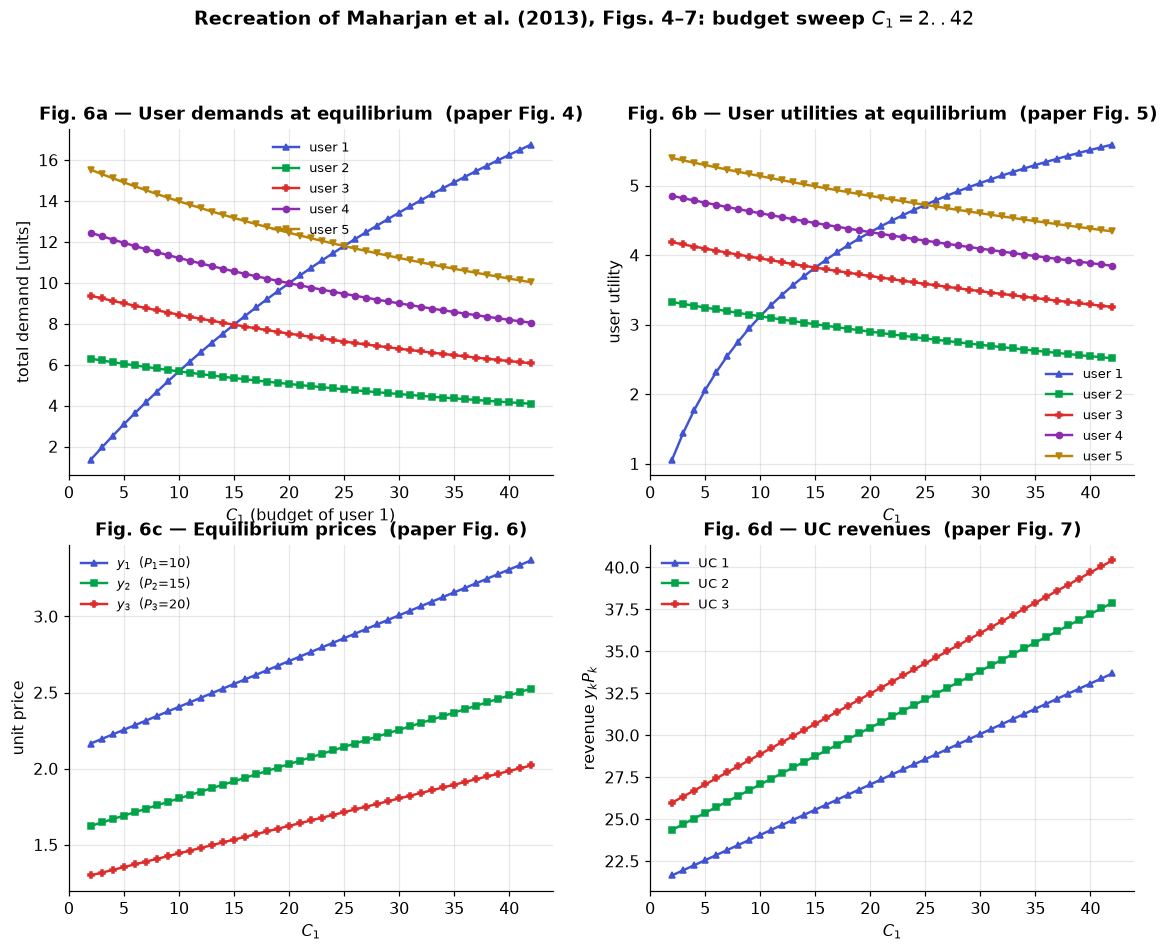

In [6]:
C1_grid = np.linspace(2, 42, 41)
dem = np.zeros((len(C1_grid), 5)); util = np.zeros((len(C1_grid), 5))
prc = np.zeros((len(C1_grid), 3)); rev = np.zeros((len(C1_grid), 3))
for i, c1 in enumerate(C1_grid):
    gi = M.paper_base_game(C1=float(c1))
    y, x = M.stackelberg_equilibrium(gi)
    dem[i], util[i] = x.sum(axis=1), M.utilities(gi, x)
    prc[i], rev[i] = y, M.revenues(gi, y, x)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.0))
markers = ["^", "s", "P", "o", "v"]

ax = axes[0, 0]
for n in range(5):
    ax.plot(C1_grid, dem[:, n], marker=markers[n], ms=4, lw=1.6, label=f"user {n+1}")
ax.set_xlabel("$C_1$ (budget of user 1)"); ax.set_ylabel("total demand [units]")
ax.set_title("Fig. 6a — User demands at equilibrium  (paper Fig. 4)")
ax.legend(fontsize=8.5)

ax = axes[0, 1]
for n in range(5):
    ax.plot(C1_grid, util[:, n], marker=markers[n], ms=4, lw=1.6, label=f"user {n+1}")
ax.set_xlabel("$C_1$"); ax.set_ylabel("user utility")
ax.set_title("Fig. 6b — User utilities at equilibrium  (paper Fig. 5)")
ax.legend(fontsize=8.5)

ax = axes[1, 0]
for k in range(3):
    ax.plot(C1_grid, prc[:, k], marker=markers[k], ms=4, lw=1.6, label=f"$y_{k+1}$  ($P_{k+1}$={int(g.P[k])})")
ax.set_xlabel("$C_1$"); ax.set_ylabel("unit price")
ax.set_title("Fig. 6c — Equilibrium prices  (paper Fig. 6)")
ax.legend(fontsize=8.5)

ax = axes[1, 1]
for k in range(3):
    ax.plot(C1_grid, rev[:, k], marker=markers[k], ms=4, lw=1.6, label=f"UC {k+1}")
ax.set_xlabel("$C_1$"); ax.set_ylabel("revenue $y_k P_k$")
ax.set_title("Fig. 6d — UC revenues  (paper Fig. 7)")
ax.legend(fontsize=8.5)

fig.suptitle("Recreation of Maharjan et al. (2013), Figs. 4–7: budget sweep $C_1 = 2..42$",
             fontweight="bold", y=1.0)
savefig(fig, RESULTS / "fig06_paper_figs4to7.png")
plt.show()

### Quantitative match against the paper

Values digitized by eye from the paper's figures (±few % reading error) vs. ours:

In [7]:
anchors = pd.DataFrame([
    ["Fig. 6 prices @C1=2",   "(2.15, 1.62, 1.30)", tuple(np.round(prc[0], 2))],
    ["Fig. 4 demands @C1=2",  "(1.4, 6.3, 9.4, 12.4, 15.5)", tuple(np.round(dem[0], 1))],
    ["Fig. 5 utility u1 @C1=2", "≈1.05", round(float(util[0, 0]), 2)],
    ["Fig. 7 revenues @C1=2", "(21.5, 24.4, 26.0)", tuple(np.round(rev[0], 1))],
    ["Fig. 6 prices @C1=42",  "(3.38, 2.53, 2.02)", tuple(np.round(prc[-1], 2))],
    ["Fig. 4 user1 demand @C1=42", "≈17", round(float(dem[-1, 0]), 1)],
], columns=["anchor", "paper (digitized)", "this recreation"])
print(anchors.to_string(index=False))

                    anchor           paper (digitized)             this recreation
       Fig. 6 prices @C1=2          (2.15, 1.62, 1.30)           (2.17, 1.62, 1.3)
      Fig. 4 demands @C1=2 (1.4, 6.3, 9.4, 12.4, 15.5) (1.4, 6.3, 9.4, 12.4, 15.5)
   Fig. 5 utility u1 @C1=2                       ≈1.05                        1.06
     Fig. 7 revenues @C1=2          (21.5, 24.4, 26.0)          (21.7, 24.4, 26.0)
      Fig. 6 prices @C1=42          (3.38, 2.53, 2.02)          (3.37, 2.53, 2.02)
Fig. 4 user1 demand @C1=42                         ≈17                        16.8


**All anchors match within figure-reading precision.** The recreation of the
equilibrium analysis is quantitatively faithful.

**Reading the four panels in power terms:**

- **(a) Demands.** User 1's demand grows almost linearly with its budget; the
  *other* users' demands **fall** as user 1 gets richer — with fixed total supply
  $\Sigma P = 45$, user 1 bids resources away from them through higher prices.
  Fixed supply + one consumer's growth = everyone else pays. A very grid-like
  scarcity story told in three curves.
- **(b) Utilities** mirror demands (log-compressed) — diminishing returns visible
  as the flattening of user 1's curve.
- **(c) Prices** rise **linearly** in $C_1$ — that's $\mathbf A\mathbf y = \mathbf F$
  with $\mathbf F = (C/K)\mathbf 1$: prices are a *linear* function of total
  purchasing power $C$. More money chasing the same 45 units ⇒ proportionally
  higher prices; pure demand-pull inflation, derived not assumed. The ordering
  $y_1 > y_2 > y_3$ is scarcity: $P_1 < P_2 < P_3$.
- **(d) Revenues** = $y_k P_k$: lines again (linear in $C_1$), with the *largest*
  supplier earning the most despite the *lowest* price — volume beats margin in
  this market.

## §5 · Scale test: 5 UCs, 100 households (paper Fig. 8)

Same construction, an order of magnitude more players — the paper's demonstration
that nothing about the equilibrium is small-scale luck. Budgets are grouped
(users 2–25: 10, 26–50: 15, 51–75: 20, 76–100: 25), user 1's budget sweeps
2 → 400, and supplies are $P = (150, 150, 200, 200, 250)$.

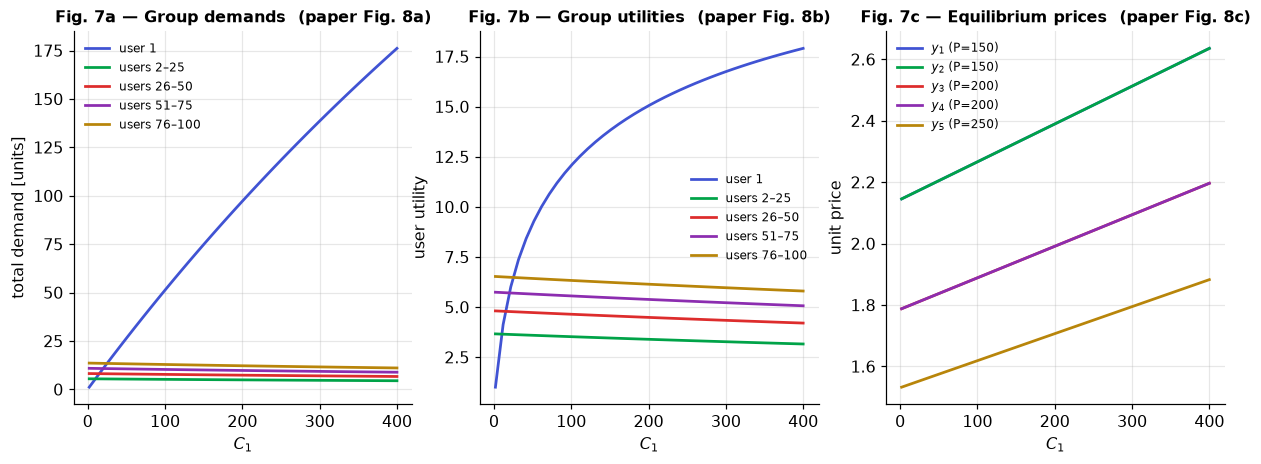

price pairing check (P1=P2 and P3=P4 ⇒ equal prices): 4.440892098500626e-16 8.881784197001252e-16


In [8]:
C1_grid8 = np.linspace(2, 400, 41)
dem8 = np.zeros((len(C1_grid8), 5)); util8 = np.zeros((len(C1_grid8), 5))
prc8 = np.zeros((len(C1_grid8), 5))
groups = {"user 1": [0], "users 2–25": range(1, 25), "users 26–50": range(25, 50),
          "users 51–75": range(50, 75), "users 76–100": range(75, 100)}
for i, c1 in enumerate(C1_grid8):
    gi = M.paper_large_game(C1=float(c1))
    y, x = M.stackelberg_equilibrium(gi)
    xt, ut = x.sum(axis=1), M.utilities(gi, x)
    dem8[i] = [np.mean(xt[list(idx)]) for idx in groups.values()]
    util8[i] = [np.mean(ut[list(idx)]) for idx in groups.values()]
    prc8[i] = y

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
for j, (ax, data, ylab, title) in enumerate([
        (axes[0], dem8, "total demand [units]", "Fig. 7a — Group demands  (paper Fig. 8a)"),
        (axes[1], util8, "user utility", "Fig. 7b — Group utilities  (paper Fig. 8b)")]):
    for s, name in enumerate(groups):
        ax.plot(C1_grid8, data[:, s], lw=1.8, label=name)
    ax.set_xlabel("$C_1$"); ax.set_ylabel(ylab); ax.set_title(title, fontsize=10.5)
    ax.legend(fontsize=8)
ax = axes[2]
labels = [f"$y_{k+1}$ (P={int(p)})" for k, p in enumerate(M.paper_large_game().P)]
for k in range(5):
    ax.plot(C1_grid8, prc8[:, k], lw=1.8, label=labels[k])
ax.set_xlabel("$C_1$"); ax.set_ylabel("unit price")
ax.set_title("Fig. 7c — Equilibrium prices  (paper Fig. 8c)", fontsize=10.5)
ax.legend(fontsize=8)
savefig(fig, RESULTS / "fig07_paper_fig8_large.png")
plt.show()

print("price pairing check (P1=P2 and P3=P4 ⇒ equal prices):",
      float(np.max(np.abs(prc8[:, 0] - prc8[:, 1]))),
      float(np.max(np.abs(prc8[:, 2] - prc8[:, 3]))))

Matches the paper's Fig. 8 structurally, including its giveaway detail: UCs with
**equal capacity post identical prices** ($y_1 = y_2$, $y_3 = y_4$ — verified to
machine precision above), so the paper's five price curves appear as three. One
household's budget growing 200× reshapes everyone's allocation smoothly; no
instability, no corner chaos — the equilibrium machinery scales.

## §6 · The distributed algorithm: equilibrium with local information only

The equilibrium so far was computed by *us*, centrally, from *everyone's* private
data ($C_n$, $P_k$ — the linear system needs $B$ and $C$). Realistic objection: no
household will upload its budget, no UC its cost structure. The paper's Section V
answer — and its most forward-looking contribution — is **Algorithm 2** (Table I):

- households see only **prices** and respond with eq. (21) — their private $C_n$
  never leaves the house;
- each UC sees only **its own total demand** $\sum_n x_{n,k}$ and adjusts its own
  price by eq. (44):

$$y_{k,t+1} \;=\; y_{k,t} + \frac{\sum_n x_{n,k,t} - P_k}{\sigma_k}$$

**A power engineer has seen this device before.** It is an *integral controller on
excess demand* — the market twin of secondary frequency control: demand above
capacity ⇒ price ramps up; below ⇒ ramps down; the integrator rests only where
$\sum_n x_{n,k} = P_k$ — which is *exactly* the sell-all condition that defined
the equilibrium. Fixed point of the controller = Stackelberg equilibrium
(Theorem 5), with $1/\sigma_k$ as the integrator gain and Theorem 5's condition
(eq. 45) as the stability margin — the very existence of which notebook 01's
Fig. 4 (hunting best responses) told us to demand.

Run it, from deliberately wrong initial prices ($y_{k,1} = 1$), with the paper's
$\sigma_k = 40$:

converged: True after 145 iterations
final prices  : [2.2556 1.6917 1.3534]
analytical y* : [2.2556 1.6917 1.3534]
max |Δ|       : 1.7045387323832983e-10


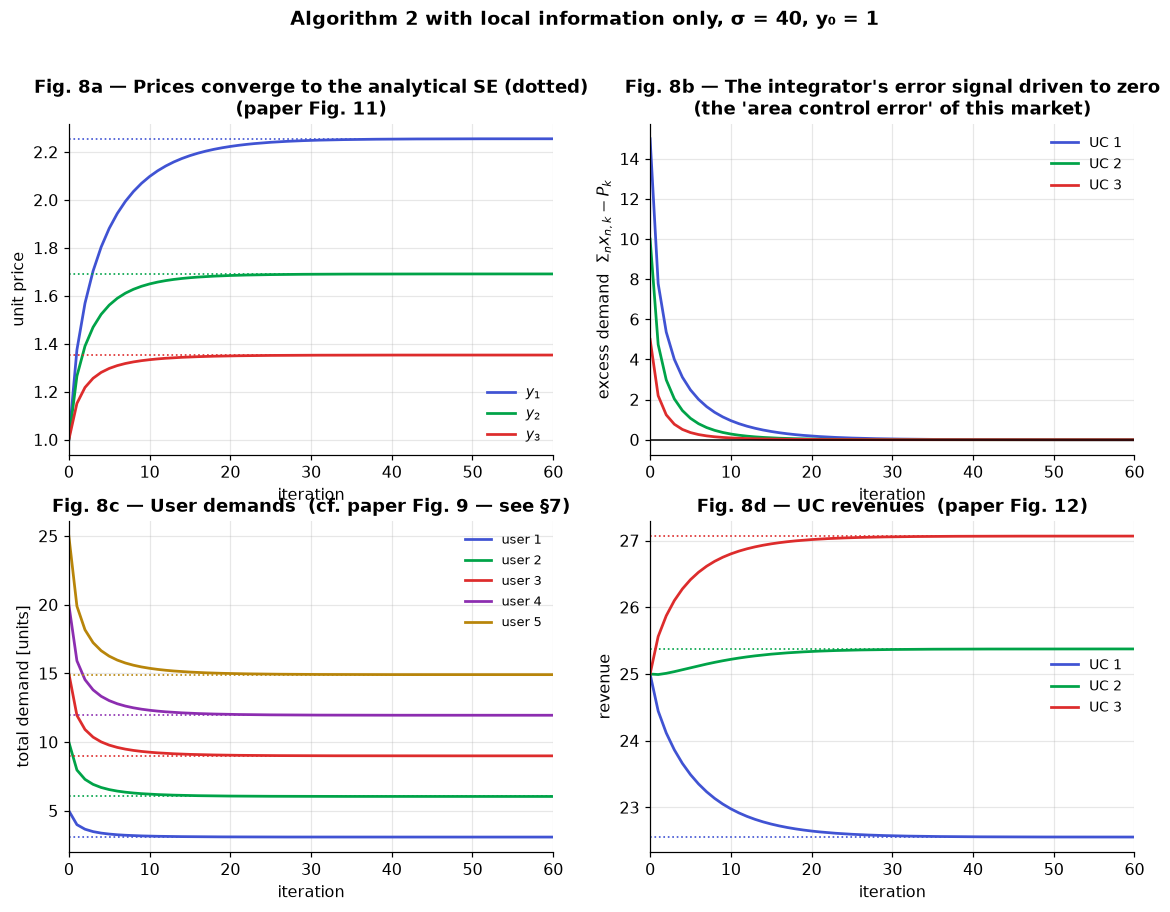

In [9]:
g5 = M.paper_base_game(C1=5.0)
y_star5, x_star5 = M.stackelberg_equilibrium(g5)
res = D.run(g5, sigma=40.0, y0=1.0, tol=1e-9)
print(f"converged: {res.converged} after {res.iterations} iterations")
print("final prices  :", res.y[-1])
print("analytical y* :", y_star5)
print("max |Δ|       :", float(np.abs(res.y[-1] - y_star5).max()))

it = np.arange(res.iterations)
fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.6))

ax = axes[0, 0]
for k in range(3):
    ax.plot(it, res.y[:, k], lw=1.8, label=f"$y_{k+1}$")
    ax.axhline(y_star5[k], color=PALETTE[k], ls=":", lw=1.1)
ax.set_xlim(0, 60); ax.set_xlabel("iteration"); ax.set_ylabel("unit price")
ax.set_title("Fig. 8a — Prices converge to the analytical SE (dotted)\n(paper Fig. 11)")
ax.legend(fontsize=9)

ax = axes[0, 1]
for k in range(3):
    ax.plot(it, res.excess[:, k], lw=1.8, label=f"UC {k+1}")
ax.axhline(0, color="k", lw=1.0)
ax.set_xlim(0, 60); ax.set_xlabel("iteration"); ax.set_ylabel(r"excess demand  $\Sigma_n x_{n,k} - P_k$")
ax.set_title("Fig. 8b — The integrator's error signal driven to zero\n(the 'area control error' of this market)")
ax.legend(fontsize=9)

ax = axes[1, 0]
for n in range(5):
    ax.plot(it, res.x_total[:, n], lw=1.8, label=f"user {n+1}")
    ax.axhline(x_star5.sum(axis=1)[n], color=PALETTE[n], ls=":", lw=1.1)
ax.set_xlim(0, 60); ax.set_xlabel("iteration"); ax.set_ylabel("total demand [units]")
ax.set_title("Fig. 8c — User demands  (cf. paper Fig. 9 — see §7)")
ax.legend(fontsize=8.5)

ax = axes[1, 1]
for k in range(3):
    ax.plot(it, res.revenue[:, k], lw=1.8, label=f"UC {k+1}")
    ax.axhline((y_star5 * x_star5.sum(axis=0))[k], color=PALETTE[k], ls=":", lw=1.1)
ax.set_xlim(0, 60); ax.set_xlabel("iteration"); ax.set_ylabel("revenue")
ax.set_title("Fig. 8d — UC revenues  (paper Fig. 12)")
ax.legend(fontsize=9)

fig.suptitle("Algorithm 2 with local information only, σ = 40, y₀ = 1", fontweight="bold", y=1.0)
savefig(fig, RESULTS / "fig08_distributed_convergence.png")
plt.show()

**Converged to the analytical equilibrium to ~10⁻⁹, using only local
information.** No entity ever saw the whole problem: the equilibrium *emerged*
from price signals and self-interested responses — the punchline of the entire
paper, reproduced.

Notice the transient in panel (c): at the initial too-low prices the households
collectively demand far more than 45 units — an infeasible ask that only exists on
paper. On a real feeder that transient would be an overload, not a bookkeeping
entry; hold that thought for Milestone 2.

### The gain–stability trade-off (paper Fig. 13)

$\sigma_k$ is an inverse gain: small σ = aggressive price moves. The sufficient
condition (eq. 45) guarantees convergence for σ large enough — but how does the
algorithm actually behave across gains, including *below* the guarantee?

eq. (45) sufficient bound near y*: sigma > 12.9


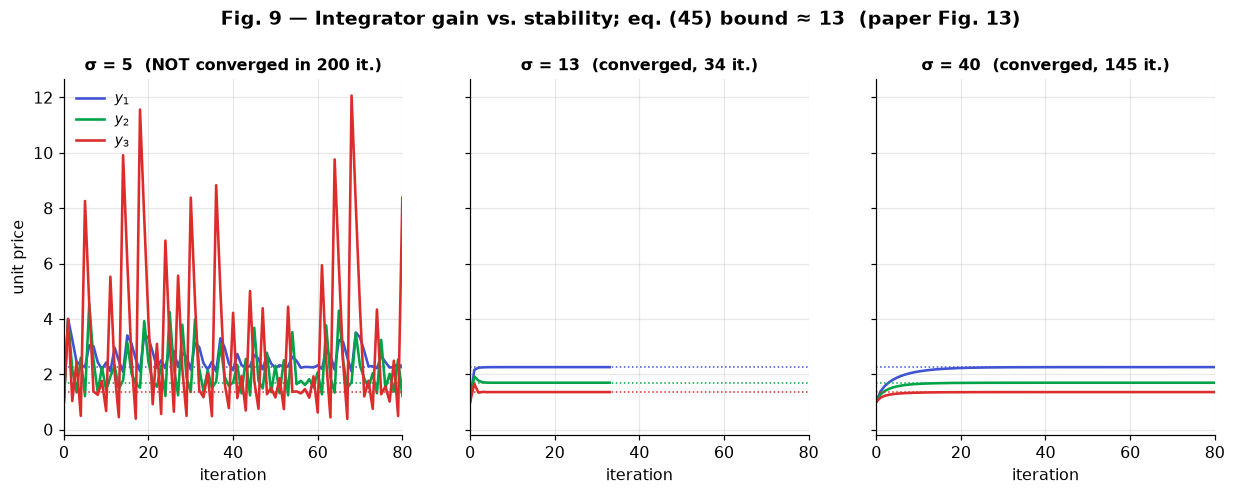

In [10]:
bound = D.sigma_sufficient(g5, y_star5)
print(f"eq. (45) sufficient bound near y*: sigma > {bound:.1f}")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), sharey=True)
for ax, s in zip(axes, [5.0, 13.0, 40.0]):
    r = D.run(g5, sigma=s, y0=1.0, tol=1e-9, max_iter=200)
    for k in range(3):
        ax.plot(r.y[:, k], lw=1.7, label=f"$y_{k+1}$")
        ax.axhline(y_star5[k], color=PALETTE[k], ls=":", lw=1.0)
    status = (f"converged, {r.iterations} it." if r.converged
              else f"NOT converged in {r.iterations} it.")
    ax.set_title(f"σ = {s:g}  ({status})", fontsize=10.5)
    ax.set_xlabel("iteration"); ax.set_xlim(0, 80)
axes[0].set_ylabel("unit price"); axes[0].legend(fontsize=9)
fig.suptitle(f"Fig. 9 — Integrator gain vs. stability; eq. (45) bound ≈ {bound:.0f}  (paper Fig. 13)",
             fontweight="bold", y=1.03)
savefig(fig, RESULTS / "fig09_sigma_sweep.png")
plt.show()

Classic integral-controller behavior, and the numbers land exactly where a
controls engineer would put them:

- **σ = 5 (gain too high): persistent hunting.** The prices overshoot the
  equilibrium every step and oscillate around it indefinitely — never converging
  in 200 iterations (and at σ = 2, off-figure, they diverge explosively). This is
  notebook 01's Fig. 4 reborn inside a real algorithm.
- **σ = 13 (≈ the eq. 45 bound): fastest convergence** — ~34 iterations to 10⁻⁹.
  The theoretical stability margin doubles as the practical tuning optimum.
- **σ = 40 (the paper's choice): safe and slow** — monotone convergence in ~145
  iterations (visually settled by ~30, matching the paper's figures).

Gain up ⇒ speed up ⇒ stability down; the sufficient bound sits right at the sweet
spot. Any engineer who has tuned an AVR knows this landscape by feel.

One more experiment the paper does *not* contain (flagged as our addition): the
paper's Theorem 5 requires **sequential** updates — UCs adjust one at a time, users
re-responding in between. What if all UCs update **simultaneously** (as real
markets might)?

In [11]:
r_seq = D.run(g5, sigma=40.0, y0=1.0, tol=1e-9)
r_sim = D.run(g5, sigma=40.0, y0=1.0, tol=1e-9, sequential=False)
print(f"sequential   : converged={r_seq.converged}  iterations={r_seq.iterations}")
print(f"simultaneous : converged={r_sim.converged}  iterations={r_sim.iterations}")
print("both reach y*:", np.allclose(r_seq.y[-1], y_star5, atol=1e-6),
      np.allclose(r_sim.y[-1], y_star5, atol=1e-6))

sequential   : converged=True  iterations=145
simultaneous : converged=True  iterations=146
both reach y*: True True


At this operating point simultaneous updating also converges (somewhat slower —
each UC reacts to slightly staler information). That is *not* guaranteed by the
paper's theorem, and in Milestone 3, where analytic best responses become
*learned* responses on stale and noisy information, this distinction — who moves
when, against how old a signal — becomes one of the central experimental axes.

## §7 · Recreation scorecard — what matched, what didn't

| Paper item | Status | Evidence |
|---|---|---|
| Eq. (21) closed-form best response | ✅ verified | 200 SLSQP cross-checks, worst dev ~10⁻⁵ (§2) |
| Theorems 1–4 (unique positive SE) | ✅ verified numerically | diagonal dominance margins, positivity, uniqueness via linear solve (§3) |
| Sell-all & budget-binding identities | ✅ exact | machine-precision equalities (§3) |
| Fig. 4 (demands vs $C_1$) | ✅ quantitative match | anchor table §4 |
| Fig. 5 (utilities) | ✅ quantitative match | anchor table §4 |
| Fig. 6 (prices) | ✅ quantitative match | anchor table §4 |
| Fig. 7 (revenues) | ✅ quantitative match | anchor table §4 |
| Fig. 8 (5 UCs, 100 users) | ✅ structural match incl. price-pairing detail | §5 |
| Fig. 11 (price convergence, σ=40) | ✅ quantitative match | converges to (2.26, 1.69, 1.35) (§6) |
| Fig. 12 (revenue convergence) | ✅ quantitative match | §6 |
| **Figs. 9–10 (demand/utility convergence)** | ⚠️ **not reproducible from stated parameters** | with $C=[5,10,15,20,25]$, $P=[10,15,20]$, converged per-user demands must sum to $\Sigma P=45$; the paper's Fig. 9 shows ≈165. Figs. 11–12 *are* consistent with the stated parameters, so Figs. 9–10 evidently used a different (unstated) $P$, possibly $C$. We reproduce the *property* (convergence to the analytical SE) with the stated parameters. Details: `LEDGER.md`. |
| Fig. 13 (σ sensitivity) | ✅ qualitative match + eq. (45) bound computed | §6 |
| Section VI (attack, reserve schemes) | ➖ out of scope for M1 | by design |

The one discrepancy is documented, bounded, and does not touch any conclusion:
the convergence *property* the figures exist to demonstrate is fully reproduced.

## §8 · What this model cannot see — the road to Milestone 2

Stand back from the recreation and list what the copperplate hides. Each blind
spot below is one milestone of this repository:

1. **No network (→ M2).** Energy flows from any UC to any household with no
   feeder, no impedance, no voltage limit. The infeasible demand transient of
   Fig. 8c and the equilibrium itself are never checked against a power flow.
   *M2 pins the households to buses of a real SimBench MV feeder and audits every
   equilibrium with AC power flow — and reprices the game with network-aware
   (DLMP-style) prices, the industrial-strength version of §3's toll from
   notebook 01.*
2. **Clairvoyant best responses (→ M3).** Eq. (21) assumes each household solves
   its problem exactly, instantly, from perfect price information. *M3 replaces it
   with learning agents that know only their own bills — and asks whether the
   equilibrium recreated here is still reachable, and how fast, on private data
   only.*
3. **No location, therefore no location-fairness (→ M4).** With no network there
   is nothing unfair about where you live. Once M2's feeder exists, electrical
   position starts deciding prices and curtailment — *M4 measures that unfairness
   and tests principled repairs (Shapley-based allocation), which double as
   explanations of every household's bill.*
4. **Single shot, deterministic.** One trading round, known parameters — no time
   coupling, no PV/load uncertainty. (Stretch goals; named, not promised.)

**Milestone 1 verdict: the analytical core of Maharjan et al. (2013) is recreated,
verified, and understood in power-system terms.** The game-theory toolkit —
equilibrium computation, best-response dynamics, gain-vs-stability tuning,
mechanism-design logic — is now implemented from scratch in `sgdr/` and ready to
be pointed at a real feeder.